<a href="https://colab.research.google.com/github/jenriver/tiny-transformer/blob/main/tiny_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import jax
import jax.numpy as jnp
import random
from collections.abc import Sequence

In [ ]:
jax.devices()

[TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]

## Data init

In [ ]:
chars_str = "0123456789+="
pad_str = "_"
MAX_LEN = len("999+999=1998")

def make_vocab(chars_str: str):
  return list(pad_str + chars_str)
vocab = make_vocab(chars_str)
print(vocab)
pad_id = vocab.index(pad_str)

['_', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', '=']


In [ ]:
def encode(s_in: str) -> list[int]:
  output = []
  for s in s_in:
    output.append(vocab.index(s))
  return output

def decode(ids: list[int]) -> str:
  s = ""
  for i in ids:
    s += vocab[i]
  return s

def rand_ndigit(n):
    return random.randint(0, 9) if n == 1 else random.randint(10**(n-1), 10**n - 1)

def make_example(max_digits=3) -> str:
    a = rand_ndigit(random.randint(1, max_digits))
    b = rand_ndigit(random.randint(1, max_digits))
    return f'{a}+{b}={a+b}'

def make_input_target(ids):
  return ids[:-1], ids[1:]

def pad_to(ids: list[int], T: int) -> tuple[list[int], list[int]]:
  n = len(ids)
  padded = ids + [pad_id] * (T-n)
  mask = [1] * n + [0] * (T-n)
  return padded, mask

def make_batch(B: int, T: int):
  inputs, targets, masks = [], [], []
  for _ in range(B):
    ids = encode(make_example()) + [pad_id]  # important! varied length
    input, target = make_input_target(ids)
    input_padded, mask = pad_to(input, T)
    target_padded, _ = pad_to(target, T)
    inputs.append(input_padded)
    targets.append(target_padded)
    masks.append(mask)
  return jnp.array(inputs), jnp.array(targets), jnp.array(masks)

input = "12+34="
print(encode(input))
print(decode(encode(input)))

[2, 3, 11, 4, 5, 12]
12+34=


In [ ]:
def init_embed(key, V, D):
  return jax.random.normal(key, (V, D)) * (1.0 / jnp.sqrt(D))

def init_pos(key, T, D):
  return jax.random.normal(key, (T, D)) * (1.0 / jnp.sqrt(D))

def embed(table, ids):
  return table[ids]  # fancy-indexing gathers

In [ ]:
# @title Dense model init

def init_attn(key, D, N, K, H):
  kq, kk, kv, ko = jax.random.split(key, 4)
  scale = 1.0 / jnp.sqrt(D)
  return {
      "Wq": jax.random.normal(kq, (D, N, H)) * scale,
      "Wk": jax.random.normal(kk, (D, K, H)) * scale,
      "Wv": jax.random.normal(kv, (D, K, H)) * scale,
      "Wo": jax.random.normal(ko, (N, H, D)) * scale,
  }

def init_cache(B, S_max, K, H, L):
  return [{"k": jnp.zeros((B, S_max, K, H)),
           "v": jnp.zeros((B, S_max, K, H))} for _ in range(L)]

def attention(input: jnp.ndarray, attn: dict, cache = None, pos: int = 0):
  B, T, D = input.shape
  _, _, H = attn["Wq"].shape
  q = jnp.einsum("btd,dnh->btnh", input, attn["Wq"])
  k = jnp.einsum("bsd,dnh->bsnh", input, attn["Wk"])
  v = jnp.einsum("bsd,dnh->bsnh", input, attn["Wv"])

  if cache is not None:
    k = jax.lax.dynamic_update_slice(cache["k"], k, (0, pos, 0, 0))
    v = jax.lax.dynamic_update_slice(cache["v"], v, (0, pos, 0, 0))
    cache = {"k": k, "v": v}

  attn_matrix = jnp.einsum("btnh,bsnh->btsn", q, k) / jnp.sqrt(H)
  S = k.shape[1]
  q_pos  = pos + jnp.arange(T)
  kv_pos = jnp.arange(k.shape[1])
  causal = q_pos[:, None] >= kv_pos[None, :]
  # causal = jnp.tril(jnp.ones((T, S), dtype=bool))
  attn_matrix = jnp.where(causal[None, :, :, None], attn_matrix, -1e30)

  w = jax.nn.softmax(attn_matrix, axis=2)
  o = jnp.einsum("btsn,bsnh->btnh", w, v)
  return jnp.einsum("btnh,nhd->btd", o, attn["Wo"]), cache

def init_mlp(key, D, F):
  kw1, kw2, kw3 = jax.random.split(key, 3)
  return {
      "w_gate": jax.random.normal(kw1, (D, F)) / jnp.sqrt(D),
      "w_up":   jax.random.normal(kw2, (D, F)) / jnp.sqrt(D),
      "w_down": jax.random.normal(kw3, (F, D)) / jnp.sqrt(F),
  }

def mlp(input: jnp.ndarray, p: dict):
  B, T, D = input.shape
  gate = jnp.einsum("btd,df->btf", input, p["w_gate"])
  up =   jnp.einsum("btd,df->btf", input, p["w_up"])
  return jnp.einsum("btf,fd->btd", jax.nn.silu(gate) * up, p["w_down"])

def init_norm(D):
  return {'g': jnp.ones(D)}

def rmsnorm(x, p, eps=1e-6):
  ms = jnp.mean(x**2, axis=-1, keepdims=True)
  return x * jax.lax.rsqrt(ms + eps) * p["g"]

def init_block_dense(key, D, N, K, H, F):
  ka, km = jax.random.split(key, 2)
  return {
      "attn": init_attn(ka, D, N, K, H),
      "mlp":   init_mlp(km, D, F),
      "norm1":  init_norm(D),
      "norm2":  init_norm(D),
  }

def init_blocks_dense(key, D, N, K, H, F, L):
  return [init_block_dense(kb, D, N, K, H, F) for kb in jax.random.split(key, L)]

def block_dense(x: jnp.ndarray, p: dict, kvcache=None, pos=0):
  attn_out, kvcache = attention(rmsnorm(x, p['norm1']), p['attn'], kvcache, pos)
  x = x + attn_out
  x = x + mlp(rmsnorm(x, p['norm2']), p['mlp'])
  return x, kvcache

def init_model_dense(key, V, T, D, N, K, H, F, L):
  kt, kp, kb, ku = jax.random.split(key, 4)
  return {
      "tok_table": init_embed(kt, V, D),
      "pos_table": init_pos(kp, T, D),
      "blocks": init_blocks_dense(kb, D, N, K, H, F, L),
      "norm": init_norm(D),
      "unembed": jax.random.normal(ku, (D, V)) / jnp.sqrt(D),
  }

def model_dense(ids, mp, kvcache=None, pos=0):
  T = ids.shape[1]
  x = mp["tok_table"][ids] + mp["pos_table"][pos + jnp.arange(T)]
  new_caches = []
  for i, p in enumerate(mp['blocks']):
    x, c = block_dense(x, p, None if kvcache is None else kvcache[i], pos)
    new_caches.append(c)
  x = rmsnorm(x, mp['norm'])
  return jnp.einsum('btd,dv->btv', x, mp['unembed']), new_caches


In [ ]:
B = 128
T = MAX_LEN
D = 128
N = 4   # number of heads for query
H = 32  # 128 / 4 = 32 (head dim)
K = 4   # = N for MHA
F = 512 # 4 * D
L = 4
V = len(vocab)


ids, targets, masks = make_batch(B, T)
key = jax.random.PRNGKey(0)
params_dense = init_model_dense(key, V, T, D, N, K, H, F, L)
x, _ = model_dense(ids, params_dense)
print(decode(jnp.argmax(x, axis=-1)[0].tolist()))

7138_8434884


In [ ]:
print(sum(p.size for p in jax.tree.leaves(params_dense)))
print(x.shape)  # B, T, V
print(jnp.isnan(x).any())

1054592
(128, 12, 13)
False


In [ ]:
print((V * D) + (T * D) + ((3 * D * F) + (4 * D * N * H) + (2 * D)) * L + D + (V * D))

1054592


In [ ]:
jit_model = jax.jit(model_dense)

def generate(params, prompt, T, K, H, L):
  caches = init_cache(1, T, K, H, L)
  ids = encode(prompt)
  logits, caches = jit_model(jnp.array([ids]), params, caches, 0)    # prefill: ONE call
  out = list(ids)
  for pos in range(len(ids), T):
    nxt = int(jnp.argmax(logits[0, -1]))
    if nxt == pad_id: break
    out.append(nxt)
    logits, caches = jit_model(jnp.array([[nxt]]), params, caches, pos)
  return decode(out)


def sample(params, prompt="456+789="): # "456+789="  # "12+34="
    ids_ = jnp.array([encode(prompt) + [pad_id]*(T-len(prompt))])
    for i in range(len(prompt), T):
        logits, _ = jit_model(ids_, params)
        nxt = jnp.argmax(logits[0, i-1])
        if nxt == pad_id: break  # early stopping
        ids_ = ids_.at[0, i].set(nxt)
    return decode(ids_[0].tolist()).split(pad_str)[0]  # rid padding to match.

for p in ["12+34=", "456+789=", "9+9=", "999+1=", "1+1="]:
    a, b = sample(params_dense, p), generate(params_dense, p, T, K, H, L)
    print(f"{'MATCH ' if a==b else 'DIFFER'} {p:10} {a!r:18} {b!r}")

MATCH  12+34=     '12+34=646444'     '12+34=646444'
MATCH  456+789=   '456+789=4'        '456+789=4'
MATCH  9+9=       '9+9=77777738'     '9+9=77777738'
MATCH  999+1=     '999+1=777777'     '999+1=777777'
MATCH  1+1=       '1+1=66666666'     '1+1=66666666'


In [ ]:
# @title MoE model init
E = 12
TOP_K = 2

def init_moe(key, D, F, E):
  kr, *ke = jax.random.split(key, E + 1)
  return {
      "router": jax.random.normal(kr, (D, E)),
      "experts" : [init_mlp(k, D, F) for k in ke],
  }

def moe(input, p):                                           # top_k comes from global TOP_K
    logits = jnp.einsum("btd,de->bte", input, p["router"])   # [B,T,E]
    topv, topi = jax.lax.top_k(logits, TOP_K)                # [B,T,k], [B,T,k]
    gate = jax.nn.softmax(topv, axis=-1)                     # [B,T,k]

    out = jnp.zeros_like(input)                              # [B,T,D]
    for e in range(len(p["experts"])):
        y_e = mlp(input, p["experts"][e])                    # [B,T,D]  run expert e on all tokens
        w_e = jnp.sum(jnp.where(topi == e, gate, 0.0), -1)   # [B,T]    weight for e (0 if not picked)
        out = out + w_e[..., None] * y_e                     # [B,T,D]  weighted add
    return out

def moe_ragged(input, p):                                    # top_k comes from global TOP_K
    B, T, D = input.shape
    _, E = p["router"].shape
    M = B*T
    experts = p["experts"]
    W_gate = jnp.stack([_p["w_gate"] for _p in experts])     # [E,D,F]
    W_up = jnp.stack([_p["w_up"] for _p in experts])         # [E,D,F]
    W_down = jnp.stack([_p["w_down"] for _p in experts])     # [E,F,D]

    logits = jnp.einsum("btd,de->bte", input, p["router"])   # [B,T,E]
    topv, topi = jax.lax.top_k(logits, TOP_K)                # [B,T,k], [B,T,k]
    gate = jax.nn.softmax(topv, axis=-1)                     # [B,T,k]

    input_reshaped = input.reshape(M, D)                     # [M,D]

    tok_of_row = jnp.repeat(jnp.arange(M), TOP_K)            # [M*k]
    exp_of_row = topi.reshape(-1)                            # [M*k]
    gate_of_row = gate.reshape(-1)                           # [M*k]
    rows = input_reshaped[tok_of_row]                        # [M,D] -> [M*k, D]

    order = jnp.argsort(exp_of_row)                          # [M*k]
    rows_sorted = rows[order]                                # [M*k, D] -> [M*k, D]
    group_sizes = jnp.bincount(exp_of_row, length=E)         # [M*k]

    rows_gate = jax.lax.ragged_dot(rows_sorted, W_gate, group_sizes)    # [M*k, D], [E,D,F] -> [M*k,F]
    rows_up = jax.lax.ragged_dot(rows_sorted, W_up, group_sizes)        # [M*k, D], [E,D,F] -> [M*k,F]
    h = jax.nn.silu(rows_gate) * rows_up                     # [M*k,F]
    out = jax.lax.ragged_dot(h, W_down, group_sizes)         # [M*k,F], [F D] -> [M*k,D]

    out = jnp.zeros((M*TOP_K, D)).at[order].set(out)
    out = (out * gate_of_row[:, None]).reshape(M, TOP_K, D).sum(1)
    return out.reshape(B, T, D)

def init_block_moe(key, D, N, K, H, F, E):
  ka, km = jax.random.split(key, 2)
  return {
      "attn": init_attn(ka, D, N, K, H),
      "moe":   init_moe(km, D, F, E),
      "norm1":  init_norm(D),
      "norm2":  init_norm(D),
  }

def init_blocks_moe(key, D, N, K, H, F, L, E):
  return [init_block_moe(kb, D, N, K, H, F, E) for kb in jax.random.split(key, L)]

def block_moe(x: jnp.ndarray, p: dict, kvcache=None, pos=0):
  attn_out, kvcache = attention(rmsnorm(x, p['norm1']), p['attn'], kvcache, pos)
  x = x + attn_out
  x = x + moe_ragged(rmsnorm(x, p['norm2']), p['moe'])
  return x, kvcache

def init_model_moe(key, V, T, D, N, K, H, F, L, E):
  kt, kp, kb, ku = jax.random.split(key, 4)
  return {
      "tok_table": init_embed(kt, V, D),
      "pos_table": init_pos(kp, T, D),
      "blocks": init_blocks_moe(kb, D, N, K, H, F, L, E),
      "norm": init_norm(D),
      "unembed": jax.random.normal(ku, (D, V)) / jnp.sqrt(D),
  }

def model_moe(ids, mp, kvcache=None, pos=0):
  T = ids.shape[1]
  x = mp["tok_table"][ids] + mp["pos_table"][pos + jnp.arange(T)]
  new_caches = []
  for i, p in enumerate(mp['blocks']):
    x, c = block_moe(x, p, None if kvcache is None else kvcache[i], pos)
    new_caches.append(c)
  x = rmsnorm(x, mp['norm'])
  return jnp.einsum('btd,dv->btv', x, mp['unembed']), new_caches

In [ ]:
ids, targets, masks = make_batch(B, T)
params_moe = init_model_moe(key, V, T, D, N, K, H, F, L, E)
x, _ = model_moe(ids, params_moe)
print(decode(jnp.argmax(x, axis=-1)[0].tolist()))

_71617714122


## Training

In [ ]:
import numpy as np
import optax
import math

opt = optax.adamw(3e-4)
opt_state = opt.init(params_dense)

def make_loss_fn(model_fn):
  def loss_fn(params, ids, targets, mask):
    logits, _ = model_fn(ids, params)
    # logp = jax.nn.log_softmax(logits, axis=-1)
    # tgt = jnp.take_along_axis(logp, targets[..., None], -1)[..., 0]
    # return -(tgt * mask).sum() / mask.sum()
    ce = optax.softmax_cross_entropy_with_integer_labels(logits, targets)   # [B,T]
    return (ce * mask).sum() / mask.sum()
  return loss_fn

def make_train_step(opt, model_fn):
  loss_fn = make_loss_fn(model_fn)
  @jax.jit
  def train_step(params, opt_state, ids, targets, masks):
      loss, grads = jax.value_and_grad(loss_fn)(params, ids, targets, masks)
      gnorm = optax.global_norm(grads)
      updates, opt_state = opt.update(grads, opt_state, params)
      return optax.apply_updates(params, updates), opt_state, loss, gnorm
  return train_step

def make_accuracy_fn(model_fn):
  @jax.jit
  def accuracy_fn(params, ids, targets, masks):
      logits, _ = model_fn(ids, params)
      pred = jnp.argmax(logits, -1)
      return ((pred == targets) * masks).sum() / masks.sum()
  return accuracy_fn


In [ ]:
loss_fn = make_loss_fn(model_dense)
init_loss = loss_fn(params_dense, ids, targets, masks)

print(f'init loss {init_loss:.3f}  |  uniform baseline ln(V) = {math.log(V):.3f}  |  expected ≈ {math.log(V)+(1**2)/2:.3f}')

init loss 2.972  |  uniform baseline ln(V) = 2.565  |  expected ≈ 3.065


In [ ]:
PROBES = {
  "1d_nocarry": [(3,4),(1,2),(5,3),(2,6)],
  "1d_carry":   [(7,8),(9,6),(5,9),(8,4)],
  "2d_nocarry": [(12,34),(21,45),(53,26),(31,44)],
  "2d_carry":   [(18,34),(57,68),(29,13),(46,37)],
  "3d_nocarry": [(123,456),(321,234),(412,145)],
  "3d_carry":   [(456,789),(678,543),(199,282)],
  "cascade":    [(999,1),(99,1),(199,801),(909,91)],
}

def batch_generate(params, prompts):
    arr  = jnp.array([encode(p) + [pad_id]*(T-len(p)) for p in prompts])
    lens = jnp.array([len(p) for p in prompts])
    for i in range(int(lens.min()), T):
        logits, _ = model_dense(arr, params)
        nxt   = jnp.argmax(logits[:, i-1], -1)
        write = i >= lens                                   # don't overwrite prompts
        arr   = arr.at[:, i].set(jnp.where(write, nxt, arr[:, i]))
    return [decode(r.tolist()).split(pad_str)[0] for r in arr]   # cut at first PAD

def evaluate(params):
    flat = [(b,a,c) for b,ps in PROBES.items() for a,c in ps]
    outs = batch_generate(params, [f"{a}+{c}=" for _,a,c in flat])
    res  = {}
    for (b,a,c), out in zip(flat, outs):
        res.setdefault(b, []).append(out == f"{a}+{c}={a+c}")
    return {b: sum(v)/len(v) for b,v in res.items()}, dict(zip(
            [(a,c) for _,a,c in flat], [o == f"{a}+{c}={a+c}" for (_,a,c),o in zip(flat,outs)]))

def show_table(first_solve, PROBES, last_step):
    print(f"{'category':14}{'solved':>8}{'median':>9}{'range':>16}")
    print("─" * 47)
    for c, items in PROBES.items():
        steps = [first_solve[i] for i in items if i in first_solve]
        k, n = len(steps), len(items)
        med = int(np.median(steps)) if k else "—"
        rng = f"({min(steps)}–{max(steps)})" if k else "—"
        print(f"{c:14}{f'{k}/{n}':>8}{str(med):>9}{rng:>16}")
    print(f"\nunsolved = censored (>{last_step} steps) — don't drop them from the story")

# ---- trackers ----
emergence  = {b: [] for b in PROBES}     # (step, accuracy) curves
first_solve = {}                          # (a,b) -> step first solved

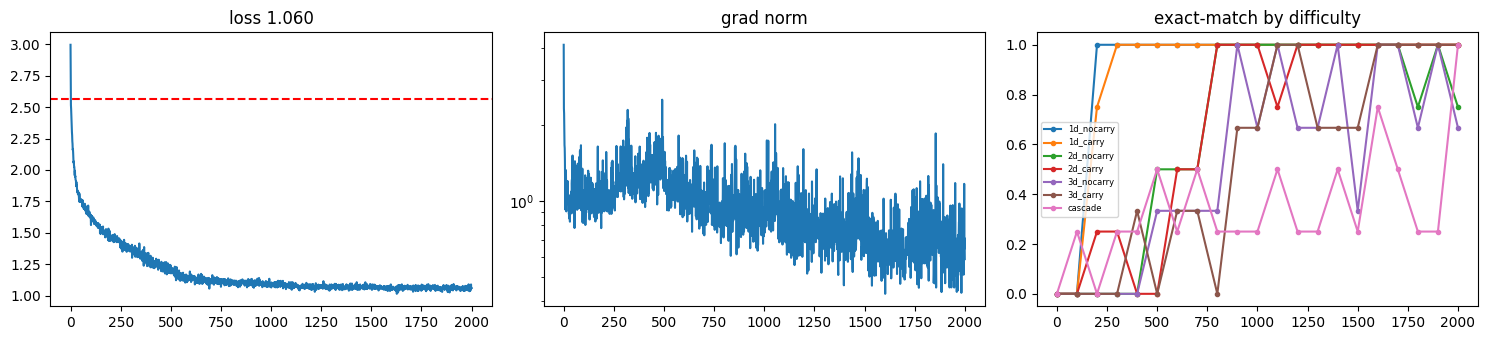

step 2000  sample: '456+789=1245'
{'1d_nocarry': '1.00', '1d_carry': '1.00', '2d_nocarry': '0.75', '2d_carry': '1.00', '3d_nocarry': '0.67', '3d_carry': '1.00', 'cascade': '1.00'}
category        solved   median           range
───────────────────────────────────────────────
1d_nocarry         4/4      200       (200–200)
1d_carry           4/4      200       (200–300)
2d_nocarry         4/4      600       (500–800)
2d_carry           4/4      450       (200–600)
3d_nocarry         3/3      900       (500–900)
3d_carry           3/3      900      (400–1100)
cascade            4/4      400      (100–1400)

unsolved = censored (>10000 steps) — don't drop them from the story


In [ ]:
import matplotlib.pyplot as plt, math
from IPython.display import clear_output

# ---------------- training loop ----------------
params  = init_model_dense(key, V, T, D, N, K, H, F, L)
opt     = optax.adamw(3e-4)
opt_state = opt.init(params)
hist = {"loss": [], "gnorm": [], "acc": []}
EVAL_EVERY = 100

train_step = make_train_step(opt, model_dense)
for step in range(2001):
    ids, targets, masks = make_batch(B, T)                 # FRESH batch each step
    params, opt_state, loss, gnorm = train_step(params, opt_state, ids, targets, masks)
    hist["loss"].append(float(loss)); hist["gnorm"].append(float(gnorm))

    if step % EVAL_EVERY == 0:
        accs, per_ex = evaluate(params)
        for b, a in accs.items(): emergence[b].append((step, a))
        for prob, ok in per_ex.items():
            if ok and prob not in first_solve:
                first_solve[prob] = step
                print(f"step {step}: FIRST SOLVED {prob[0]}+{prob[1]}={prob[0]+prob[1]}")

        clear_output(wait=True)
        fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
        ax[0].plot(hist["loss"]); ax[0].axhline(math.log(V), ls='--', c='r'); ax[0].set_title(f"loss {loss:.3f}")
        ax[1].plot(hist["gnorm"]); ax[1].set_yscale('log'); ax[1].set_title("grad norm")
        for b, pts in emergence.items():
            if pts: ax[2].plot(*zip(*pts), marker='o', ms=3, label=b)
        ax[2].set_ylim(-.05,1.05); ax[2].legend(fontsize=6); ax[2].set_title("exact-match by difficulty")
        plt.tight_layout(); plt.show()
        print(f"step {step}  sample: {sample(params)!r}")
        print({b: f"{a:.2f}" for b,a in accs.items()})

show_table(first_solve, PROBES, 10000)

In [ ]:
# @title Fit Chinchilla Scaling Law
"""
L(P, Tok) =        E        +      A/P^α       +      B/Tok^β
               can never         too small a        haven't seen
               remove            model              enough data

- E: irreducible entropy of language. Perfect model at infinite data hits ~0.

P varied by manipulating d_model and layers
toks varied based on training steps
"""

def train_run_dense(d_model, n_layers, train_steps=1500, lr=3e-4, B=128, eval_every=250):
  n_heads, d_ff = max(1, d_model // H), 4 * d_model
  params = init_model_dense(key, V, T, d_model, n_heads, n_heads, H, d_ff, n_layers)
  n_params = sum(p.size for p in jax.tree.leaves(params))
  opt = optax.adamw(lr); opt_state = opt.init(params)
  step_fn = make_train_step(opt, model_dense)
  eval_ids, eval_tg, eval_mk = make_batch(512, T)
  rows = []
  eval_loss = make_loss_fn(model_dense)
  for step in range(1, train_steps + 1):
      ids, targets, masks = make_batch(B, T)
      params, opt_state, loss, gnorm = step_fn(params, opt_state, ids, targets, masks)
      if step % eval_every == 0:
          rows.append(dict(P=n_params, tok=B*T*step,
                           loss=float(eval_loss(params, eval_ids, eval_tg, eval_mk)),
                           gnorm=float(gnorm)))
  return rows

def moe_params(D, N, F, L, E, k, active):
    ffn = (k if active else E) * (3*D*F)      # active = k experts, total = E experts
    per_block = 4*D*N*H + ffn + D*E + 2*D      # attn + ffn + router + norms
    return (V*D) + (T*D) + per_block*L + D + (V*D)

def train_run_moe(d_model, n_layers, train_steps=5000, lr=3e-4, B=128, eval_every=250):
    n_heads, d_ff = max(1, d_model // H), 4*d_model
    params = init_model_moe(key, V, T, d_model, n_heads, n_heads, H, d_ff, n_layers, E)
    opt = optax.adamw(lr); opt_state = opt.init(params)
    step_fn = make_train_step(opt, model_moe)           # same as make_train_step but calls model_moe
    eval_ids, eval_tg, eval_mk = make_batch(512, T)
    total  = moe_params(d_model, n_heads, d_ff, n_layers, E, TOP_K, active=False)
    active = moe_params(d_model, n_heads, d_ff, n_layers, E, TOP_K, active=True)
    rows = []
    eval_loss = make_loss_fn(model_moe)
    for step in range(1, train_steps+1):
        ids, tg, mk = make_batch(B, T)
        params, opt_state, loss, _ = step_fn(params, opt_state, ids, tg, mk)
        if step % eval_every == 0:
            rows.append(dict(P=active, total=total, tok=B*T*step,
                             loss=float(eval_loss(params, eval_ids, eval_tg, eval_mk))))
    return rows

params_sweep = [
    (64,  2),   #    134K
    (96,  2),   #    299K
    (128, 2),   #    530K
    (256, 2),   #   2.11M
    (128, 4),   #   1.05M
    # (256, 4),   #   4.21M
    # (320, 4),   #   6.57M
    # (384, 6),   #   14.2M
]
sweep_dense = []
for d_model, n_layers in params_sweep:
    sweep_dense += train_run_dense(d_model, n_layers, train_steps=1500)

sweep_moe = []
for d, nl in params_sweep:
    sweep_moe += train_run_moe(d, nl, train_steps=1500)


In [ ]:
# @title fit chinchilla debug
from scipy.optimize import curve_fit

sweep_P, sweep_tok, sweep_loss = zip(*[(r['P'], r['tok'], r['loss']) for r in sweep_dense])
sweep_P = np.array(sweep_P) / 1e6
sweep_tok = np.array(sweep_tok) / 1e6

def chinchilla_law(X, E, A, B, alpha, beta):
    P, tok = X
    return E + A/P**alpha + B/tok**beta

(E, A, B, alpha, beta), _ = curve_fit(chinchilla_law, (sweep_P, sweep_tok), sweep_loss, p0=[0.1, 1, 1, 0.3, 0.3], maxfev=100000)

print(E, A, B, alpha, beta)

for i in range(len(sweep_dense)):
  true_loss = sweep_loss[i]
  pred_loss = E + A/sweep_P[i]**alpha + B/sweep_tok[i]**beta
  if i < 10:
    print(f'true loss: {true_loss} vs. predicted loss: {pred_loss}')

0.27977428145689326 0.11408441949853669 0.7819180176401325 0.5591612355776678 0.2556454535645779
true loss: 1.6094409227371216 vs. predicted loss: 1.62971611739004
true loss: 1.5126314163208008 vs. predicted loss: 1.467543262154381
true loss: 1.4340238571166992 vs. predicted loss: 1.3851777109733847
true loss: 1.3304684162139893 vs. predicted loss: 1.3317052826116171
true loss: 1.2694014310836792 vs. predicted loss: 1.292854018778532
true loss: 1.211130976676941 vs. predicted loss: 1.2627148832004802
true loss: 1.5264039039611816 vs. predicted loss: 1.5025184478409537
true loss: 1.4279357194900513 vs. predicted loss: 1.3403455926052943
true loss: 1.2815921306610107 vs. predicted loss: 1.2579800414242985
true loss: 1.1656110286712646 vs. predicted loss: 1.2045076130625305


dense: alpha=0.559 beta=0.256 E=0.280 -> U possible
MoE: alpha=0.141 beta=0.317 E=0.000 -> alpha~0: NO U (saturated)


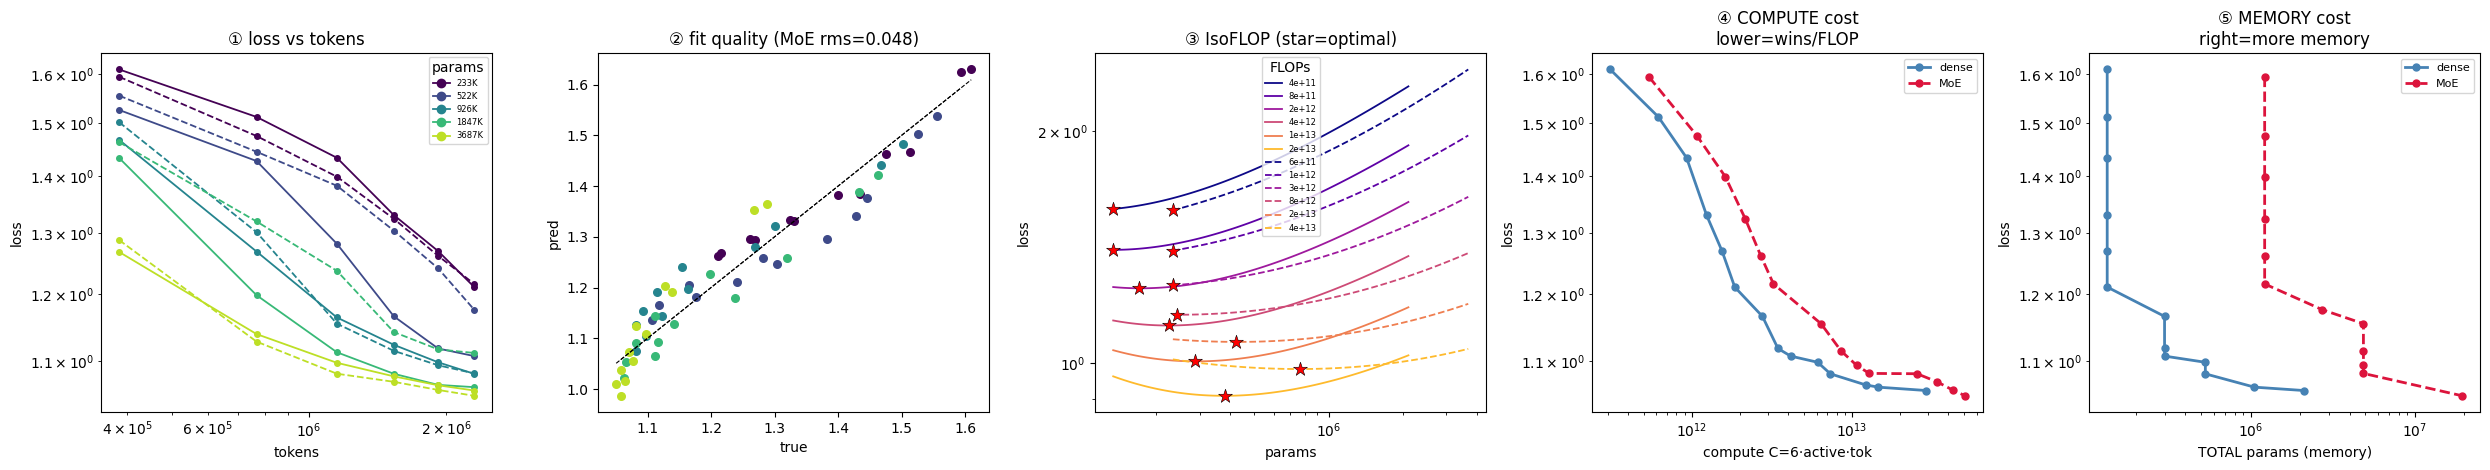

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def chinchilla_law(X, E, A, B, alpha, beta):
    P, tok = X
    return E + A/P**alpha + B/tok**beta

def fit_law(P,tok,loss):
    lo=[0,0,0,1e-3,1e-3]; hi=[min(loss),1e3,1e3,1,1]
    return curve_fit(chinchilla_law,(P/1e6,tok/1e6),loss,
                     p0=[min(loss),1,1,.3,.3],bounds=(lo,hi),maxfev=200000)[0]

def _front(x,loss):
    o=np.argsort(x); best=np.inf; fx,fl=[],[]
    for xx,ll in zip(np.asarray(x)[o],np.asarray(loss)[o]):
        if ll<best: best=ll; fx.append(xx); fl.append(ll)
    return fx,fl

def chinchilla_report(sweep, label="dense", ls="-", axes=None):
    P    = np.array([r['P']                 for r in sweep], float)   # active (FLOP)
    Ptot = np.array([r.get('total', r['P']) for r in sweep], float)   # total (memory)
    tok  = np.array([r['tok']  for r in sweep], float)
    loss = np.array([r['loss'] for r in sweep], float)
    E,A,B,al,be = fit_law(P,tok,loss)
    print(f"{label}: alpha={al:.3f} beta={be:.3f} E={E:.3f} -> "
          f"{'U possible' if al>0.15 else 'alpha~0: NO U (saturated)'}")

    sizes = sorted(set(P)); cmap = plt.cm.viridis(np.linspace(0,.9,len(sizes)))
    csize = {s:c for s,c in zip(sizes,cmap)}
    if axes is None: _, axes = plt.subplots(1,5, figsize=(25,4.8))
    ax = axes

    # ① loss vs tokens -- color = size
    for s in sizes:
        m=P==s; ax[0].plot(tok[m], loss[m], ls, color=csize[s], marker="o", ms=4, lw=1.3)
    ax[0].set(xscale="log",yscale="log",xlabel="tokens",ylabel="loss",title="① loss vs tokens")

    # ② pred vs true -- color = size
    pred=chinchilla_law((P/1e6,tok/1e6),E,A,B,al,be); rms=np.sqrt(np.mean((pred-loss)**2))
    for s in sizes:
        m=P==s; ax[1].scatter(loss[m],pred[m],color=csize[s],s=30)
    lo,hi=loss.min(),loss.max(); ax[1].plot([lo,hi],[lo,hi],"k--",lw=.8)
    ax[1].set(xlabel="true",ylabel="pred",title=f"② fit quality ({label} rms={rms:.3f})")

    # ③ IsoFLOP from fit -- color = budget
    C=6*P*tok; budgets=np.logspace(np.log10(C.min()*1.2),np.log10(C.max()*.8),6)
    Ng=np.logspace(np.log10(P.min()),np.log10(P.max()),80)
    for c,Cb in zip(plt.cm.plasma(np.linspace(0,.85,6)),budgets):
        Dg=Cb/(6*Ng); L=chinchilla_law((Ng/1e6,Dg/1e6),E,A,B,al,be)
        ax[2].plot(Ng,L,ls,color=c,lw=1.3,label=f"{Cb:.0e}")
        i=np.argmin(L); ax[2].scatter(Ng[i],L[i],color="red",marker="*",s=110,zorder=5,edgecolor="k",lw=.4)
    ax[2].set(xscale="log",yscale="log",xlabel="params",ylabel="loss",title="③ IsoFLOP (star=optimal)")
    ax[2].legend(fontsize=6,title="FLOPs",loc="upper center")

    # ④ compute frontier
    col = "crimson" if label=="MoE" else "steelblue"
    fx,fl=_front(C,loss); ax[3].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=label)
    ax[3].set(xscale="log",yscale="log",xlabel="compute C=6·active·tok",ylabel="loss",
              title="④ COMPUTE cost\nlower=wins/FLOP"); ax[3].legend(fontsize=8)

    # ⑤ memory frontier
    fx,fl=_front(Ptot,loss); ax[4].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=label)
    ax[4].set(xscale="log",yscale="log",xlabel="TOTAL params (memory)",ylabel="loss",
              title="⑤ MEMORY cost\nright=more memory"); ax[4].legend(fontsize=8)

    # legends: size (colors) on ①, architecture (line style) on ②
    size_handles=[Line2D([0],[0],color=csize[s],marker="o",lw=1.3,label=f"{int(s/1e3)}K") for s in sizes]
    ax[0].legend(handles=size_handles,fontsize=6,title="params",loc="upper right")
    return axes

# dense solid, MoE dashed, overlaid on same axes:
ax = chinchilla_report(sweep_dense, "dense", "-")
chinchilla_report(sweep_moe, "MoE", "--", axes=ax)
# ax = chinchilla_report(sweep_moe, "MoE", "--", axes=ax)
plt.tight_layout(); plt.show()

In [ ]:
def debug_checks(params, model_fn, expected_params=None, tag=""):
    """Run after any model change. Catches the silent-wrong bugs."""
    got = sum(p.size for p in jax.tree.leaves(params))
    ids, tg, mk = make_batch(128, T)
    logits, _ = model_fn(ids, params)
    loss = float((optax.softmax_cross_entropy_with_integer_labels(logits, tg) * mk).sum() / mk.sum())
    want = math.log(V) + 0.5
    print(f"[{tag}]")
    print(f"  params    {got:>10,}" + (f"  vs {expected_params:,}  {'OK' if got==expected_params else 'MISMATCH'}" if expected_params else ""))
    print(f"  no NaN    {not bool(jnp.isnan(logits).any())}")
    print(f"  init loss {loss:.3f}  vs ln(V)+½={want:.3f}  {'OK' if abs(loss-want)<0.2 else 'check init scale'}")

def overfit_one_batch(model_fn, init_fn, steps=300):
    """Architecture sanity: one fixed batch should drive loss → ~0. If not, arch bug."""
    p = init_fn(key); opt = optax.adamw(1e-3); st = opt.init(p)
    step_fn = make_train_step(opt, model_fn)
    ids, tg, mk = make_batch(64, T)
    for _ in range(steps): p, st, loss, _ = step_fn(p, st, ids, tg, mk)
    print(f"  overfit-one-batch loss after {steps}: {float(loss):.3f}  {'OK (<0.3)' if loss<0.3 else 'arch bug'}")

def expert_utilization(params, block=0):
    """MoE-only: is the router collapsing to a few experts? Flat = healthy."""
    r = params['blocks'][block]['moe']['router']
    ids, _, _ = make_batch(256, T)
    x = params['tok_table'][ids] + params['pos_table'][jnp.arange(T)]
    logits = jnp.einsum('btd,de->bte', x, r)
    _, topi = jax.lax.top_k(logits, TOP_K)
    counts = jnp.bincount(topi.reshape(-1), length=r.shape[1])
    ratio = float(counts.max() / (counts.min() + 1))
    print(f"  expert counts {counts.tolist()}")
    print(f"  max/min ratio {ratio:.1f}  {'OK (balanced)' if ratio<5 else 'router collapse — needs load-balancing'}")

# run them:
debug_checks(params_dense, model_dense, tag="dense")
debug_checks(params_moe,   model_moe,   tag="MoE")
expert_utilization(params_moe)                    # after training — watch for collapse

[dense]
  params     1,054,592
  no NaN    True
  init loss 3.078  vs ln(V)+½=3.065  OK
[MoE]
  params     9,711,488
  no NaN    True
  init loss 2.796  vs ln(V)+½=3.065  check init scale
  expert counts [503, 339, 394, 748, 433, 710, 551, 583, 411, 547, 458, 467]
  max/min ratio 2.2  OK (balanced)


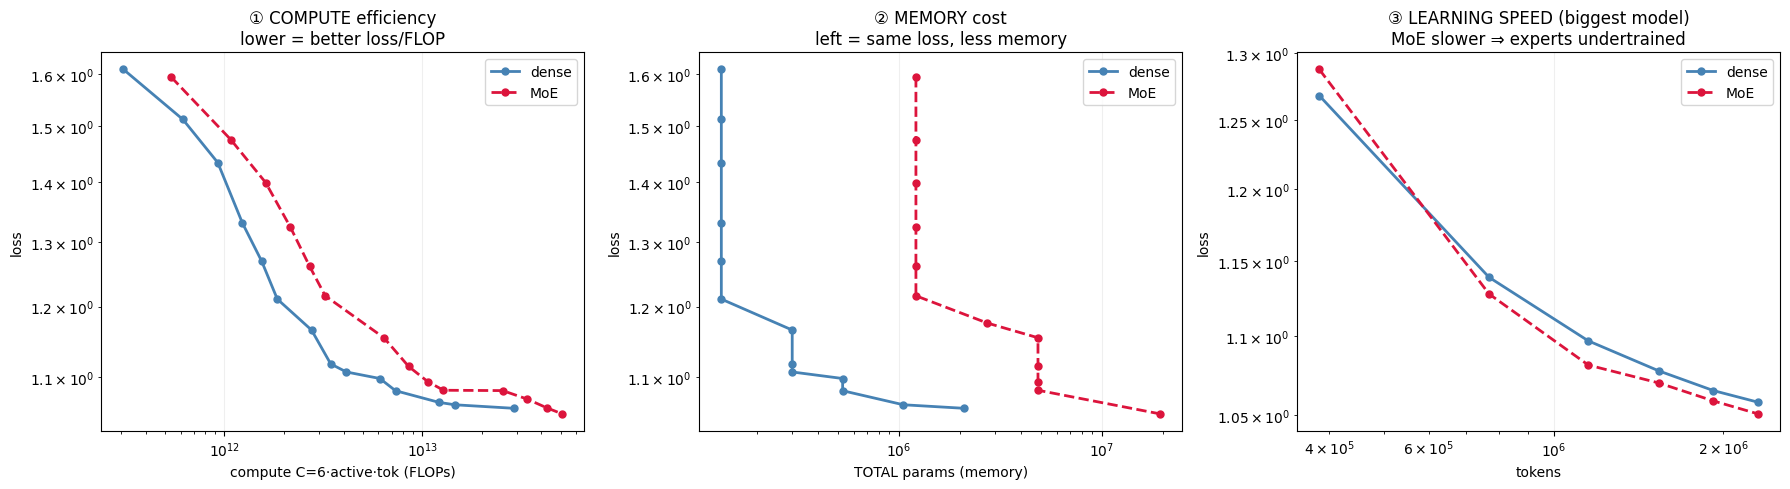

In [ ]:
import numpy as np, matplotlib.pyplot as plt

def _front(x, loss):
    o=np.argsort(x); best=np.inf; fx,fl=[],[]
    for xx,ll in zip(np.asarray(x)[o], np.asarray(loss)[o]):
        if ll<best: best=ll; fx.append(xx); fl.append(ll)
    return fx,fl

def compare(sweep_dense, sweep_moe):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    for name,(sw,col,ls) in {"dense":(sweep_dense,"steelblue","-"),
                             "MoE":(sweep_moe,"crimson","--")}.items():
        P    = np.array([r['P']                 for r in sw], float)   # ACTIVE (FLOP) params
        Ptot = np.array([r.get('total', r['P']) for r in sw], float)   # TOTAL (memory) params
        tok  = np.array([r['tok']  for r in sw], float)
        loss = np.array([r['loss'] for r in sw], float)
        C = 6*P*tok                                                     # FLOPs use ACTIVE
        fx,fl=_front(C,loss);    ax[0].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=name)
        fx,fl=_front(Ptot,loss); ax[1].plot(fx,fl,ls,color=col,marker="o",ms=5,lw=2,label=name)
        big=P==P.max(); ax[2].plot(tok[big],loss[big],ls,color=col,marker="o",ms=5,lw=2,label=f"{name}")
    ax[0].set(xscale="log",yscale="log",xlabel="compute C=6·active·tok (FLOPs)",ylabel="loss",
              title="① COMPUTE efficiency\nlower = better loss/FLOP")
    ax[1].set(xscale="log",yscale="log",xlabel="TOTAL params (memory)",ylabel="loss",
              title="② MEMORY cost\nleft = same loss, less memory")
    ax[2].set(xscale="log",yscale="log",xlabel="tokens",ylabel="loss",
              title="③ LEARNING SPEED (biggest model)\nMoE slower ⇒ experts undertrained")
    for a in ax: a.legend(fontsize=10); a.grid(alpha=.2)
    plt.tight_layout(); plt.show()

compare(sweep_dense, sweep_moe)

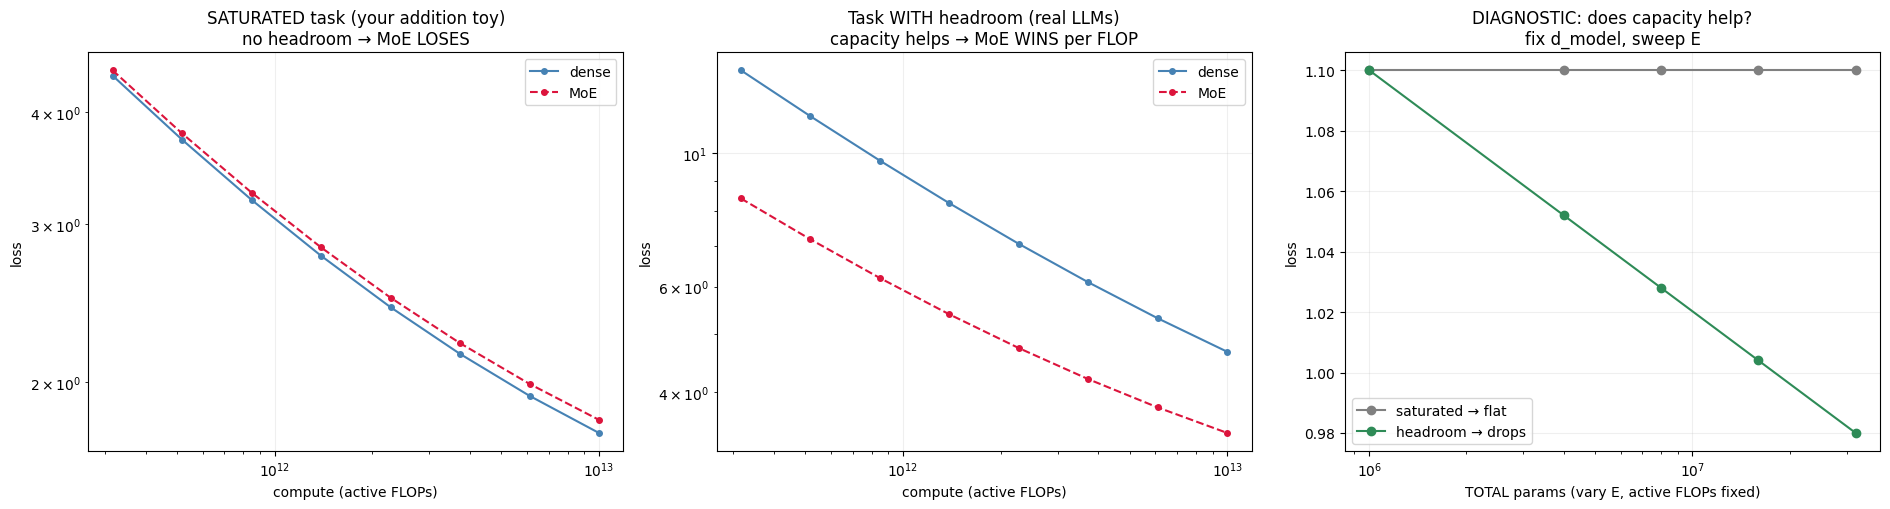

In [ ]:
import numpy as np, matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
C = np.logspace(11.5, 13, 8)

# --- Panel 1: SATURATED task (your addition toy) — capacity useless → MoE loses ---
dense_sat = 1.05 + 5e5/C**0.45
moe_sat   = 1.05 + 5e5/C**0.45 + 0.06        # overhead, no benefit
ax[0].plot(C, dense_sat, "-o", color="steelblue", ms=4, label="dense")
ax[0].plot(C, moe_sat,   "--o", color="crimson",  ms=4, label="MoE")
ax[0].set(xscale="log", yscale="log", xlabel="compute (active FLOPs)", ylabel="loss",
          title="SATURATED task (your addition toy)\nno headroom → MoE LOSES")

# --- Panel 2: task WITH headroom (real LLMs) — capacity helps → MoE wins ---
dense_hd = 1.9 + 8e5/C**0.42
moe_hd   = 1.9 + 8e5/C**0.42 * 0.55          # extra params (free FLOPs) lower loss
ax[1].plot(C, dense_hd, "-o", color="steelblue", ms=4, label="dense")
ax[1].plot(C, moe_hd,   "--o", color="crimson",  ms=4, label="MoE")
ax[1].set(xscale="log", yscale="log", xlabel="compute (active FLOPs)", ylabel="loss",
          title="Task WITH headroom (real LLMs)\ncapacity helps → MoE WINS per FLOP")

# --- Panel 3: the DIAGNOSTIC concept — flat=saturated, drops=capacity helps ---
E = np.array([1,4,8,16,32]); total = E*1e6
ax[2].plot(total, 1.10 + 0*E,                       "-o", color="gray",     ms=6, label="saturated → flat")
ax[2].plot(total, 1.10 - 0.12*np.log2(E)/np.log2(32),"-o", color="seagreen", ms=6, label="headroom → drops")
ax[2].set(xscale="log", xlabel="TOTAL params (vary E, active FLOPs fixed)", ylabel="loss",
          title="DIAGNOSTIC: does capacity help?\nfix d_model, sweep E")

for a in ax: a.legend(); a.grid(alpha=.2)
plt.tight_layout(); plt.show()

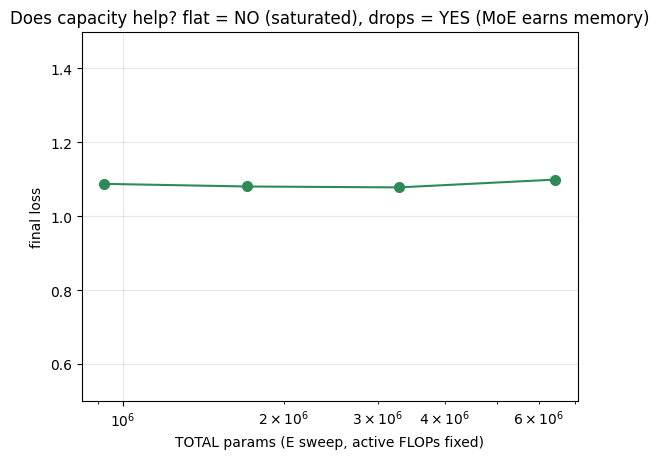

[(923520, 1.0878320932388306),
 (1710464, 1.0807071924209595),
 (3284352, 1.0782960653305054),
 (6432128, 1.0993708372116089)]

In [ ]:
def diagnostic_vary_E(d_model=128, n_layers=2, E_list=(2,4,8,16), train_steps=1500):
    """Fix d_model (≈fixed active FLOPs), sweep E. Flat = capacity useless; drops = MoE helps."""
    global E
    pts = []
    for E_ in E_list:
        E = E_                                              # the global your MoE reads
        rows = train_run_moe(d_model, n_layers, train_steps=train_steps)
        pts.append((rows[-1]['total'], rows[-1]['loss']))   # final loss vs total params
    tot, loss = zip(*pts)
    plt.plot(tot, loss, "-o", ms=7, color="seagreen")
    plt.xscale("log"); plt.xlabel("TOTAL params (E sweep, active FLOPs fixed)"); plt.ylabel("final loss")
    plt.ylim(0.5, 1.5)
    plt.title("Does capacity help? flat = NO (saturated), drops = YES (MoE earns memory)")
    plt.grid(alpha=.3); plt.show()
    return pts

diagnostic_vary_E()          # on addition → expect FLAT (your proof it's saturated)

In [ ]:
def compare_table(sweep_dense, sweep_moe):
    d = sweep_dense[-1]; m = sweep_moe[-1]     # final checkpoint of biggest model
    print(f"{'':12}{'active(FLOP)':>14}{'total(mem)':>13}{'final loss':>12}")
    print("─"*51)
    print(f"{'dense':12}{d['P']:>14,}{d.get('total',d['P']):>13,}{d['loss']:>12.3f}")
    print(f"{'MoE':12}{m['P']:>14,}{m['total']:>13,}{m['loss']:>12.3f}")
    print(f"\nMoE stores {m['total']/d.get('total',d['P']):.1f}× the params, "
          f"computes {m['P']/d['P']:.1f}× the FLOPs, for {m['loss']-d['loss']:+.3f} loss.")
    print("→ saturated task: extra capacity unused, so MoE pays memory+FLOPs for nothing. Dense wins.")

compare_table(sweep_dense, sweep_moe)

              active(FLOP)   total(mem)  final loss
───────────────────────────────────────────────────
dense            1,054,592    1,054,592       1.063
MoE              1,847,168    9,711,488       1.111

MoE stores 9.2× the params, computes 1.8× the FLOPs, for +0.049 loss.
→ saturated task: extra capacity unused, so MoE pays memory+FLOPs for nothing. Dense wins.


params:  dense 133,824   MoE 822,976   (same ACTIVE FLOPs: k=1)

Task A — ADDITION (algorithm):
  dense                  final loss 1.054
  MoE (E=8, k=1)         final loss 1.054

Task B — 12k RANDOM FACTS (memorization):
  dense                  final loss 1.130
  MoE (E=8, k=1)         final loss 0.875
  dense F×8              final loss 0.673


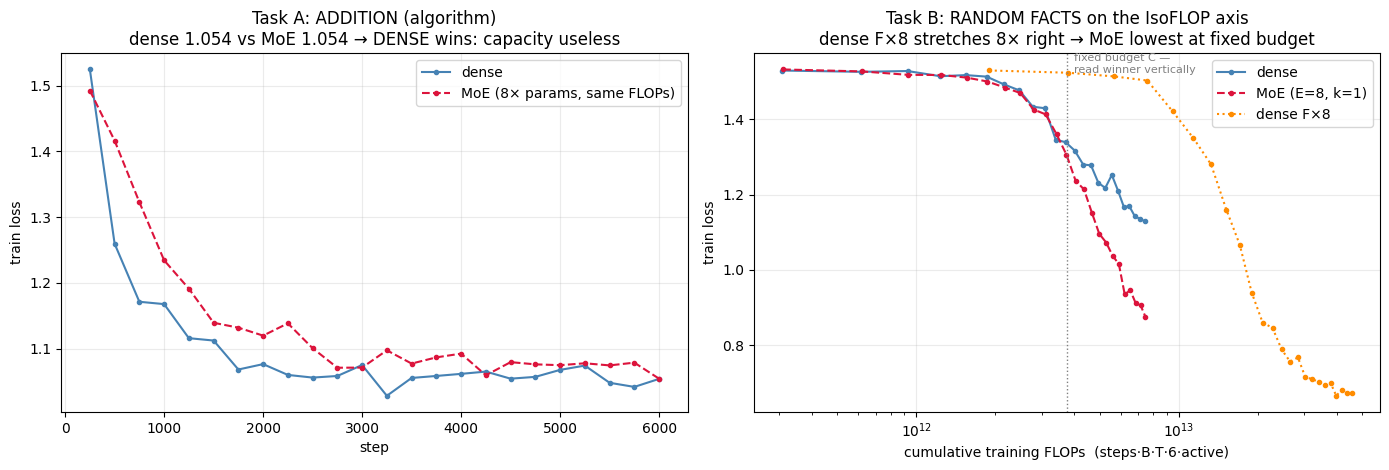


════════════════════════════ THE LESSON ════════════════════════════
Task A (algorithm)    → dense 1.054 vs MoE 1.054: capacity buys nothing.
Task B (memorization) → at a FIXED FLOP budget (vertical slice):
  dense F×1  : 1× params/FLOP-rate → loss 1.130   (out of storage)
  dense F×8  : 8× params, but 8× FLOPs/step → curve shifts 8× right
  MoE E=8,k=1: 8× params at 1× FLOPs/step → lowest loss per FLOP

Steps are not a cost — chips×time are. On the FLOPs axis, MoE = 
dense-F×8's storage at dense-F×1's price. And inference repays it on
every token, forever. That is why frontier LLMs are MoE.
(Caveat: this axis assumes equal MFU; MoE's real-world MFU is lower —
closing that gap is what MoE kernel engineering is for.)
═════════════════════════════════════════════════════════════════════


In [ ]:
# @title MoE wins in memorization-heavy tasks (typically language)

E, TOP_K = 8, 1              # overrides the globals your moe() reads
d_model, n_layers = 64, 2
n_heads, d_ff = d_model // H, 4 * d_model

_rng = random.Random(0)
N_FACTS = 12_000
_f = []
for _ in range(N_FACTS):
    s = f"{_rng.randint(100,999)}+{_rng.randint(100,999)}={_rng.randint(1000,1998)}"
    ids0 = encode(s) + [pad_id]; inp, tgt = ids0[:-1], ids0[1:]; n = len(inp)
    _f.append((inp+[pad_id]*(T-n), tgt+[pad_id]*(T-n), [1]*n+[0]*(T-n)))
FACTS = tuple(jnp.array([r[i] for r in _f]) for i in range(3))

def batch_facts(bs):
    idx = np.random.randint(0, N_FACTS, bs)
    return FACTS[0][idx], FACTS[1][idx], FACTS[2][idx]

def run(model_fn, init_params, batch_fn, steps=6000, lr=1e-3, tag=""):
    params = init_params
    opt = optax.adamw(lr); opt_state = opt.init(params)
    step_fn = make_train_step(opt, model_fn)
    curve = []
    for s in range(1, steps+1):
        ids_, tg_, mk_ = batch_fn(128)
        params, opt_state, loss, _ = step_fn(params, opt_state, ids_, tg_, mk_)
        if s % 250 == 0: curve.append((s, float(loss)))
    print(f"  {tag:22} final loss {float(loss):.3f}")
    return curve, float(loss)

def pcount(p): return sum(a.size for a in jax.tree.leaves(p))

print("params:  dense", f"{pcount(init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers)):,}",
      "  MoE", f"{pcount(init_model_moe(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers,E)):,}",
      f"  (same ACTIVE FLOPs: k={TOP_K})\n")

print("Task A — ADDITION (algorithm):")
cA_d, lA_d = run(model_dense, init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers),
                 lambda b: make_batch(b, T), tag="dense")
cA_m, lA_m = run(model_moe,   init_model_moe(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers,E),
                 lambda b: make_batch(b, T), tag="MoE (E=8, k=1)")

print("\nTask B — 12k RANDOM FACTS (memorization):")
cB_d, lB_d = run(model_dense, init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers),
                 batch_facts, tag="dense")
cB_m, lB_m = run(model_moe,   init_model_moe(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers,E),
                 batch_facts, tag="MoE (E=8, k=1)")
cB_d8, lB_d8 = run(model_dense,
    init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff*8,n_layers),
    batch_facts, tag="dense F×8")

# ---- active params per architecture (for the FLOPs axis: C = steps·B·T·6·active) ----
Pd  = pcount(init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff,n_layers))
Pd8 = pcount(init_model_dense(key,V,T,d_model,n_heads,n_heads,H,d_ff*8,n_layers))
Pm  = Pd + d_model*E*n_layers          # MoE active: 1 expert (= dense FFN) + router

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

# Panel 1 — Task A on steps (fair here: both do the same FLOPs/step at k=1)
ax[0].plot(*zip(*cA_d), "-o",  color="steelblue", ms=3, label="dense")
ax[0].plot(*zip(*cA_m), "--o", color="crimson",  ms=3, label="MoE (8× params, same FLOPs)")
ax[0].set(xlabel="step", ylabel="train loss",
          title=f"Task A: ADDITION (algorithm)\ndense {lA_d:.3f} vs MoE {lA_m:.3f} → "
                f"{'DENSE wins' if lA_d<lA_m else 'MoE wins'}: capacity useless")
ax[0].legend(); ax[0].grid(alpha=.25)

# Panel 2 — Task B on the HONEST axis: cumulative FLOPs (what frontier labs buy)
for c, P, st, col, lab in [(cB_d,  Pd,  "-",  "steelblue", "dense"),
                           (cB_m,  Pm,  "--", "crimson",   "MoE (E=8, k=1)"),
                           (cB_d8, Pd8, ":",  "darkorange","dense F×8")]:
    xs = [s*128*T*6*P for s, _ in c]; ys = [l for _, l in c]
    ax[1].plot(xs, ys, st, color=col, marker="o", ms=3, label=lab)
Cbudget = np.exp(0.5*(np.log(min(s*128*T*6*Pm for s,_ in cB_m)) +
                      np.log(max(s*128*T*6*Pd8 for s,_ in cB_d8))))
ax[1].axvline(Cbudget, color="gray", ls=":", lw=1)
ax[1].text(Cbudget, ax[1].get_ylim()[1], "  fixed budget C —\n  read winner vertically",
           fontsize=8, va="top", color="gray")
ax[1].set(xscale="log", xlabel="cumulative training FLOPs  (steps·B·T·6·active)", ylabel="train loss",
          title="Task B: RANDOM FACTS on the IsoFLOP axis\n"
                "dense F×8 stretches 8× right → MoE lowest at fixed budget")
ax[1].legend(); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

print(f"""
════════════════════════════ THE LESSON ════════════════════════════
Task A (algorithm)    → dense {lA_d:.3f} vs MoE {lA_m:.3f}: capacity buys nothing.
Task B (memorization) → at a FIXED FLOP budget (vertical slice):
  dense F×1  : 1× params/FLOP-rate → loss {lB_d:.3f}   (out of storage)
  dense F×8  : 8× params, but 8× FLOPs/step → curve shifts 8× right
  MoE E=8,k=1: 8× params at 1× FLOPs/step → lowest loss per FLOP

Steps are not a cost — chips×time are. On the FLOPs axis, MoE =
dense-F×8's storage at dense-F×1's price. And inference repays it on
every token, forever. That is why frontier LLMs are MoE.
(Caveat: this axis assumes equal MFU; MoE's real-world MFU is lower —
closing that gap is what MoE kernel engineering is for.)
═════════════════════════════════════════════════════════════════════""")